# Action potential waveforms are state-dependent
### 2. Electrical stimulation causally influences spike waveform

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

If spike waveforms carry information about a neuron's state, then changing the input a neuron receives should change the shape of its spikes, not just how often it fires. Here we test this directly: the same neuron was driven with different kinds of injected current, and we ask whether the `spikewise` waveform features of its spikes reflect what it was being driven with.

The notebook has two parts. **Part 1** asks whether the *type* of stimulation (constant, ramp, or pink noise) can be decoded from spike shape. **Part 2** zooms in on the pink noise, a continuously fluctuating input, and asks whether spike shape tracks the properties of the input in the moments right before each spike.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys
import pandas as pd

sys.path.append('finding_notebooks_functions/')
from finding2_functions import (plot_example_sweeps, plot_classifier_results,
                                pink_window_schematic_explorer, load_ridge_results, plot_r2_across_windows,
                                pink_window_explorer)

# all data used here ships with the repo (see finding_notebooks_data/build_finding2_data.py)
DATA_DIR = 'finding_notebooks_data/finding2/'

## The pvc-6 dataset

pvc-6 (Berg, 2014; CRCNS) contains whole-cell patch clamp recordings from neurons in slices of adult mouse visual cortex, sampled at 200 kHz. While recording, the experimenters injected current into each neuron in three different patterns:
- **constant current**: a fixed level of current, either a brief pulse (3 ms) or a sustained step (1 to 3 s);
- **ramp current**: current that increases linearly over time;
- **pink noise**: current that fluctuates randomly, with more power at low frequencies (a 1/f spectrum), similar to naturalistic synaptic input.

<img src="finding_notebooks_data/paper_figures/fig2_E.png" width="550">

Two neurons are available: Cell 1, an SST+ interneuron (820 spikes), and Cell 2, an unmarked neuron (380 spikes). The analyses below use Cell 1, since Cell 2 was recorded with only one ramp sweep.

<img src="AP_empirical_paper_all_analyses/paper_aux_figs/pvc6/pvc6_dataset_summary.png" width="900">

Below: one example sweep of each stimulation type from Cell 1, with the injected current on top and the neuron's membrane voltage underneath.

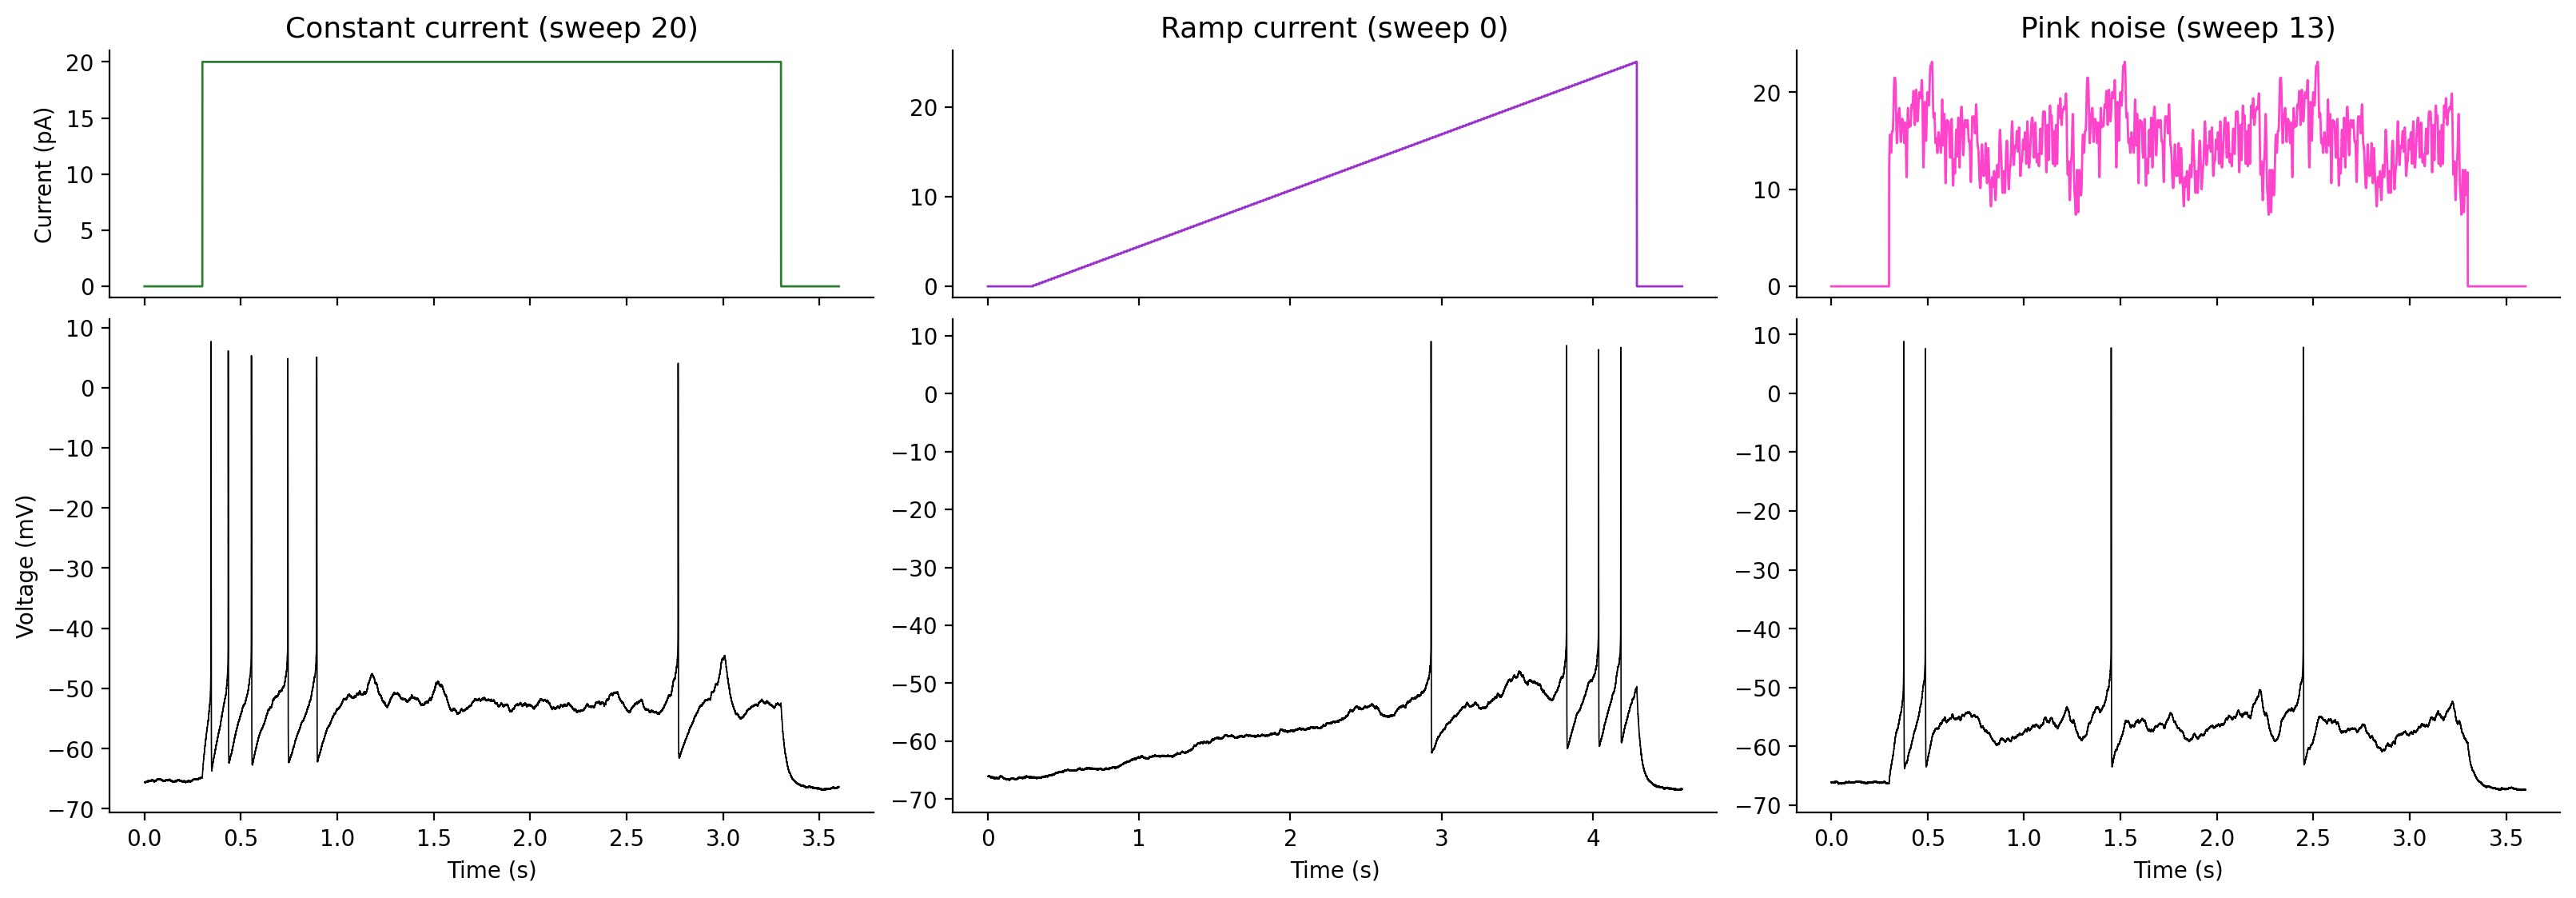

In [2]:
plot_example_sweeps(DATA_DIR)

## Part 1: Can the stimulation type be decoded from spike shape?

<img src="finding_notebooks_data/paper_figures/fig3_A.png" width="900">

We trained a random forest classifier to predict which of the three stimulation types produced each spike, using only its `spikewise` waveform features (no firing rate or timing information). To make sure every spike is scored by a model that never saw it during training, predictions are out-of-fold across 5-fold cross-validation, and the whole procedure is repeated 1000 times with different splits.

The classifier identifies the stimulation type well above chance. Pink noise spikes are recognized most reliably, while constant current spikes are the ones most often confused (mostly with pink noise). The features that carry the most information are the decay constant and peak amplitude, followed by the decay rate (Fig. 3B, C).

Out-of-fold accuracy: 78.4% +/- 0.7% across 1000 repeated 5-fold splits (chance = 33.3%)


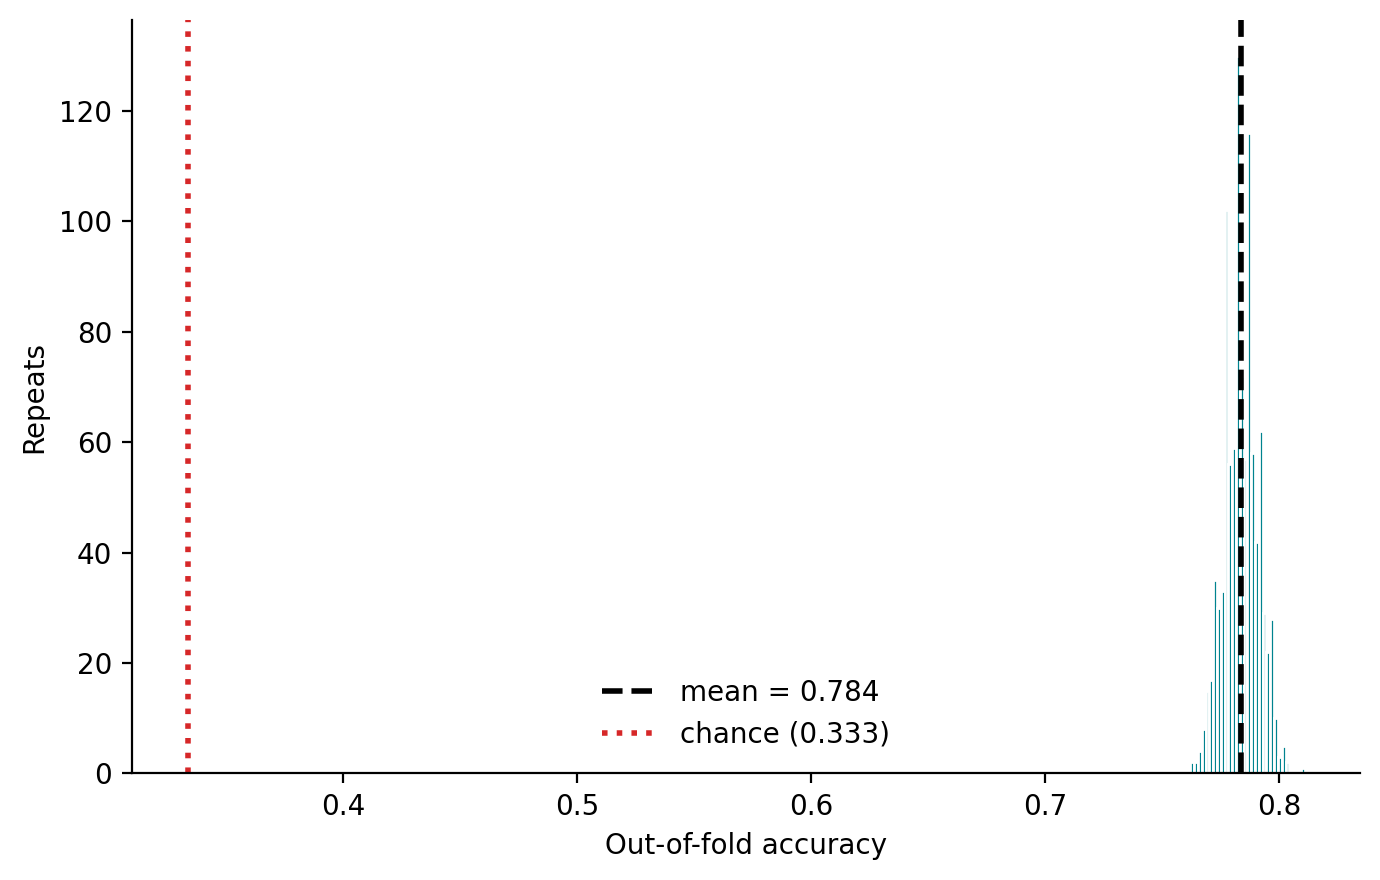

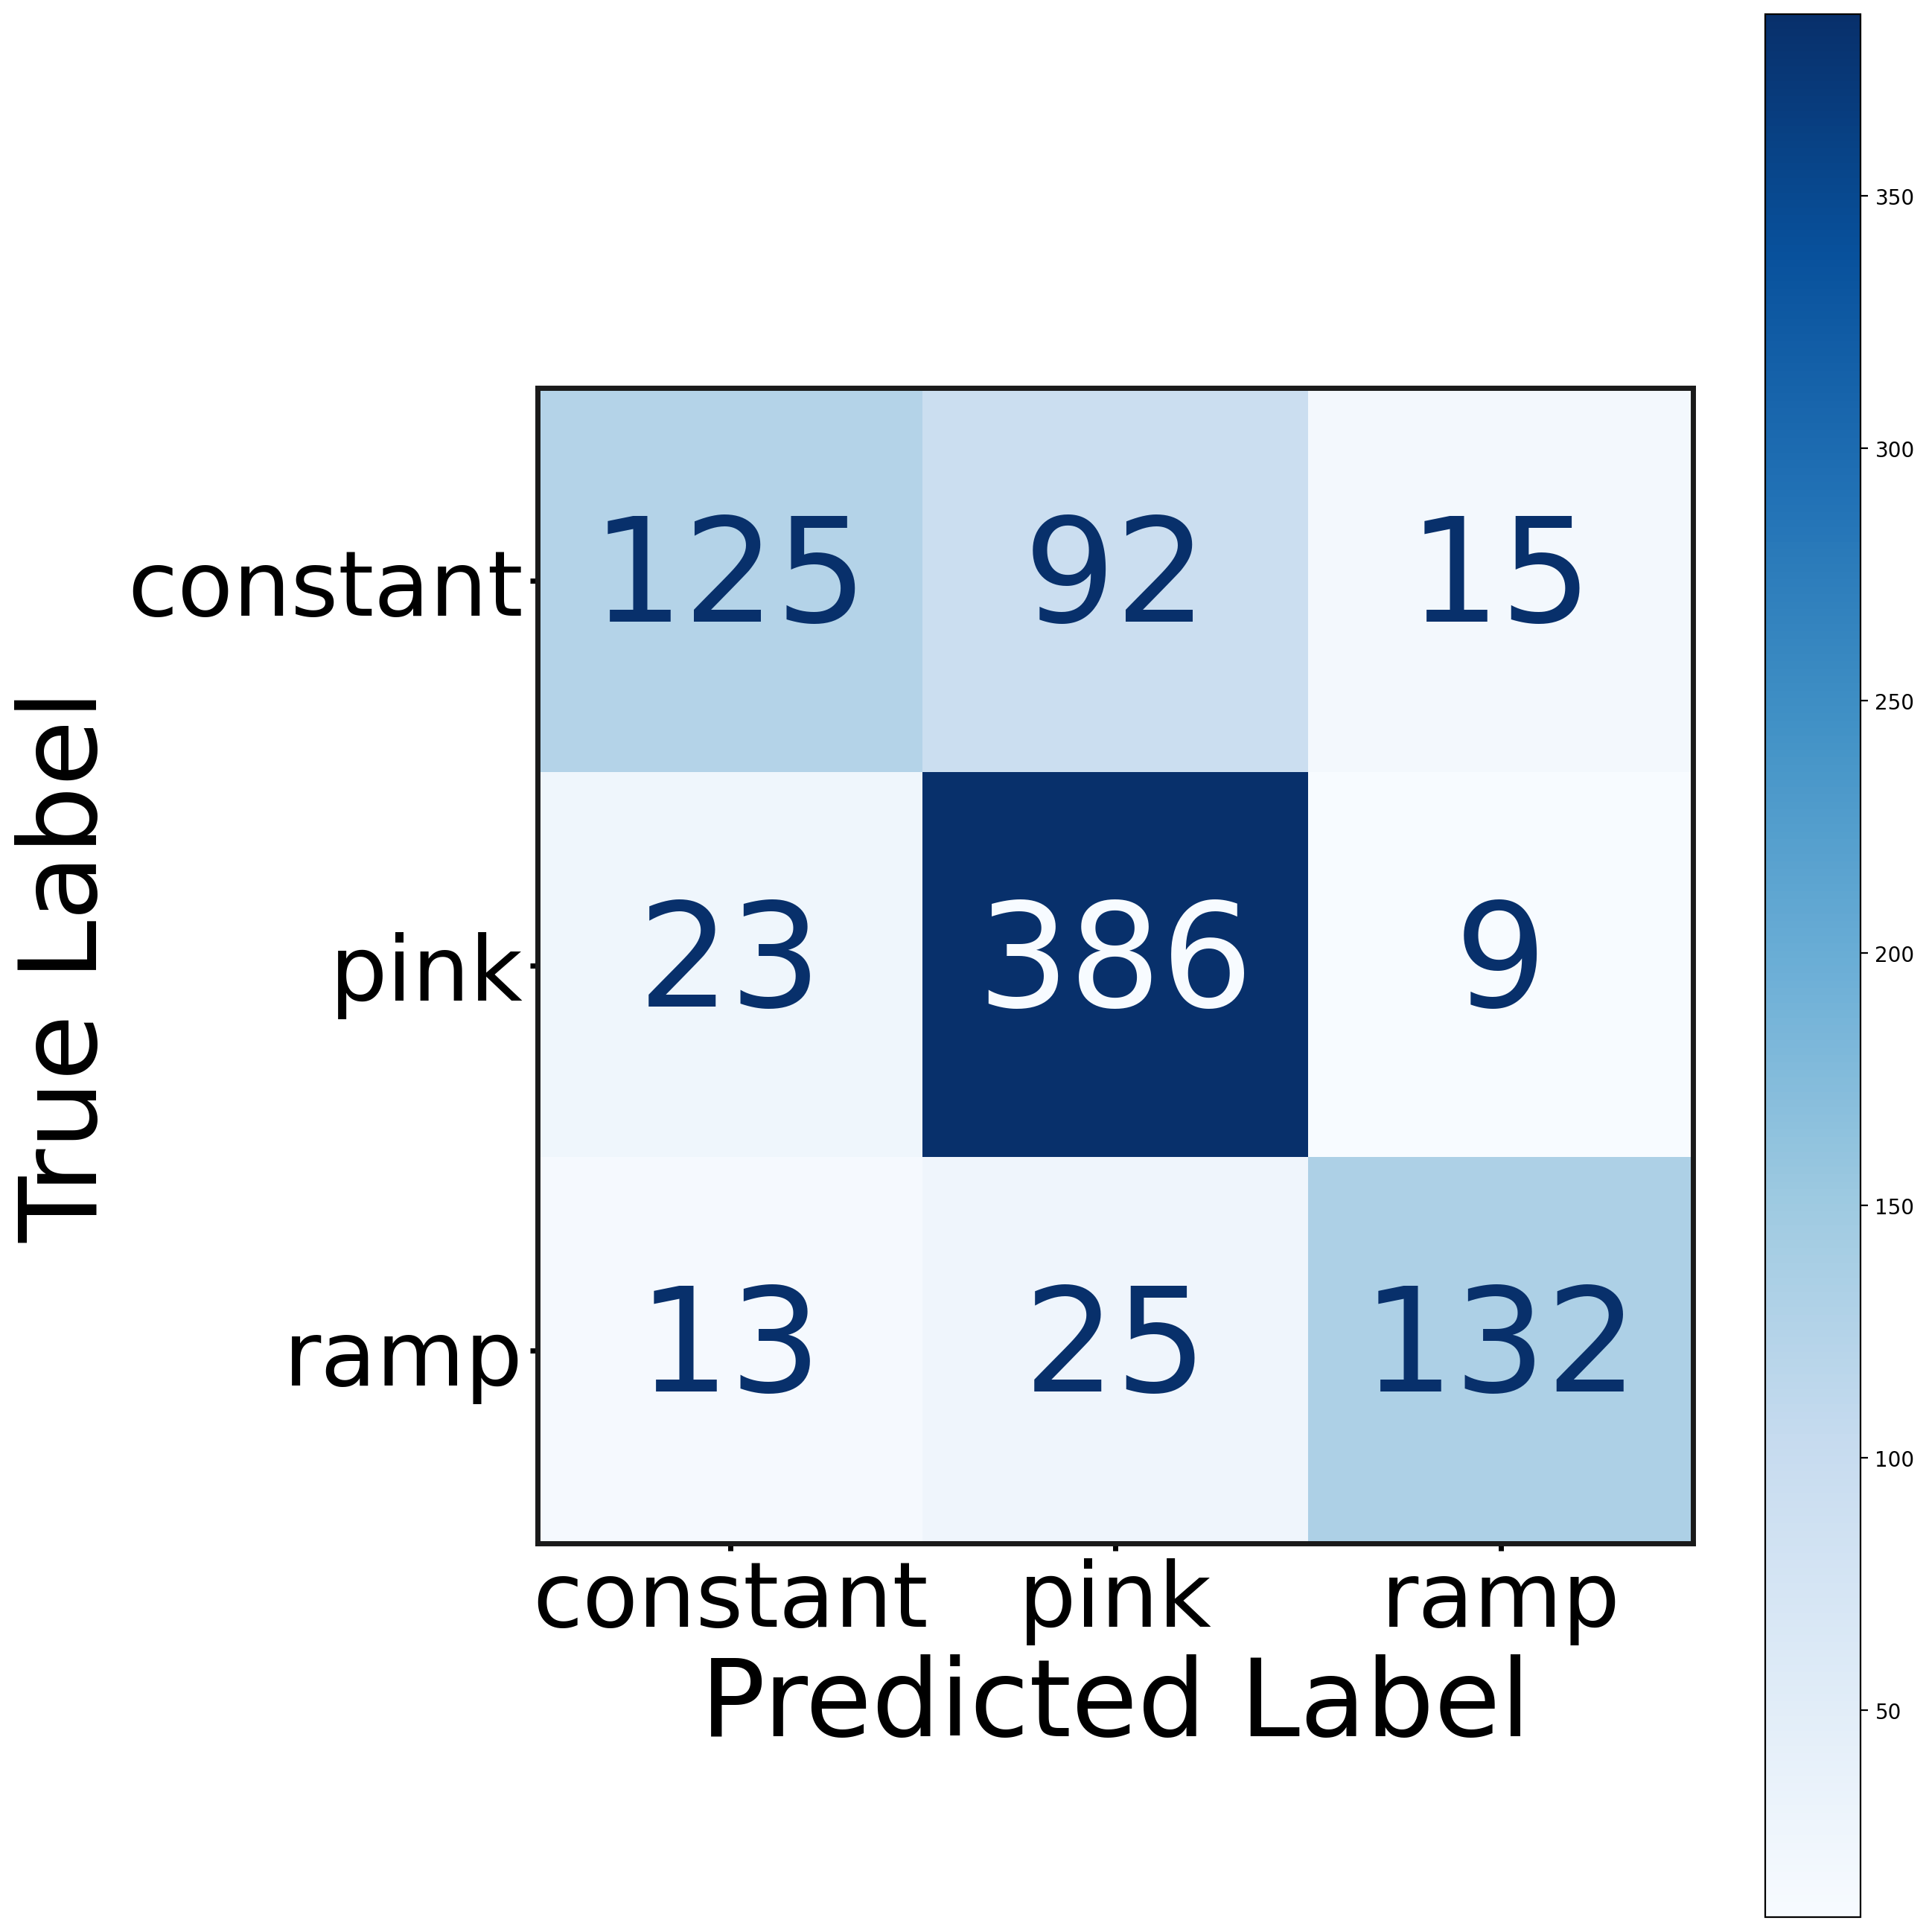

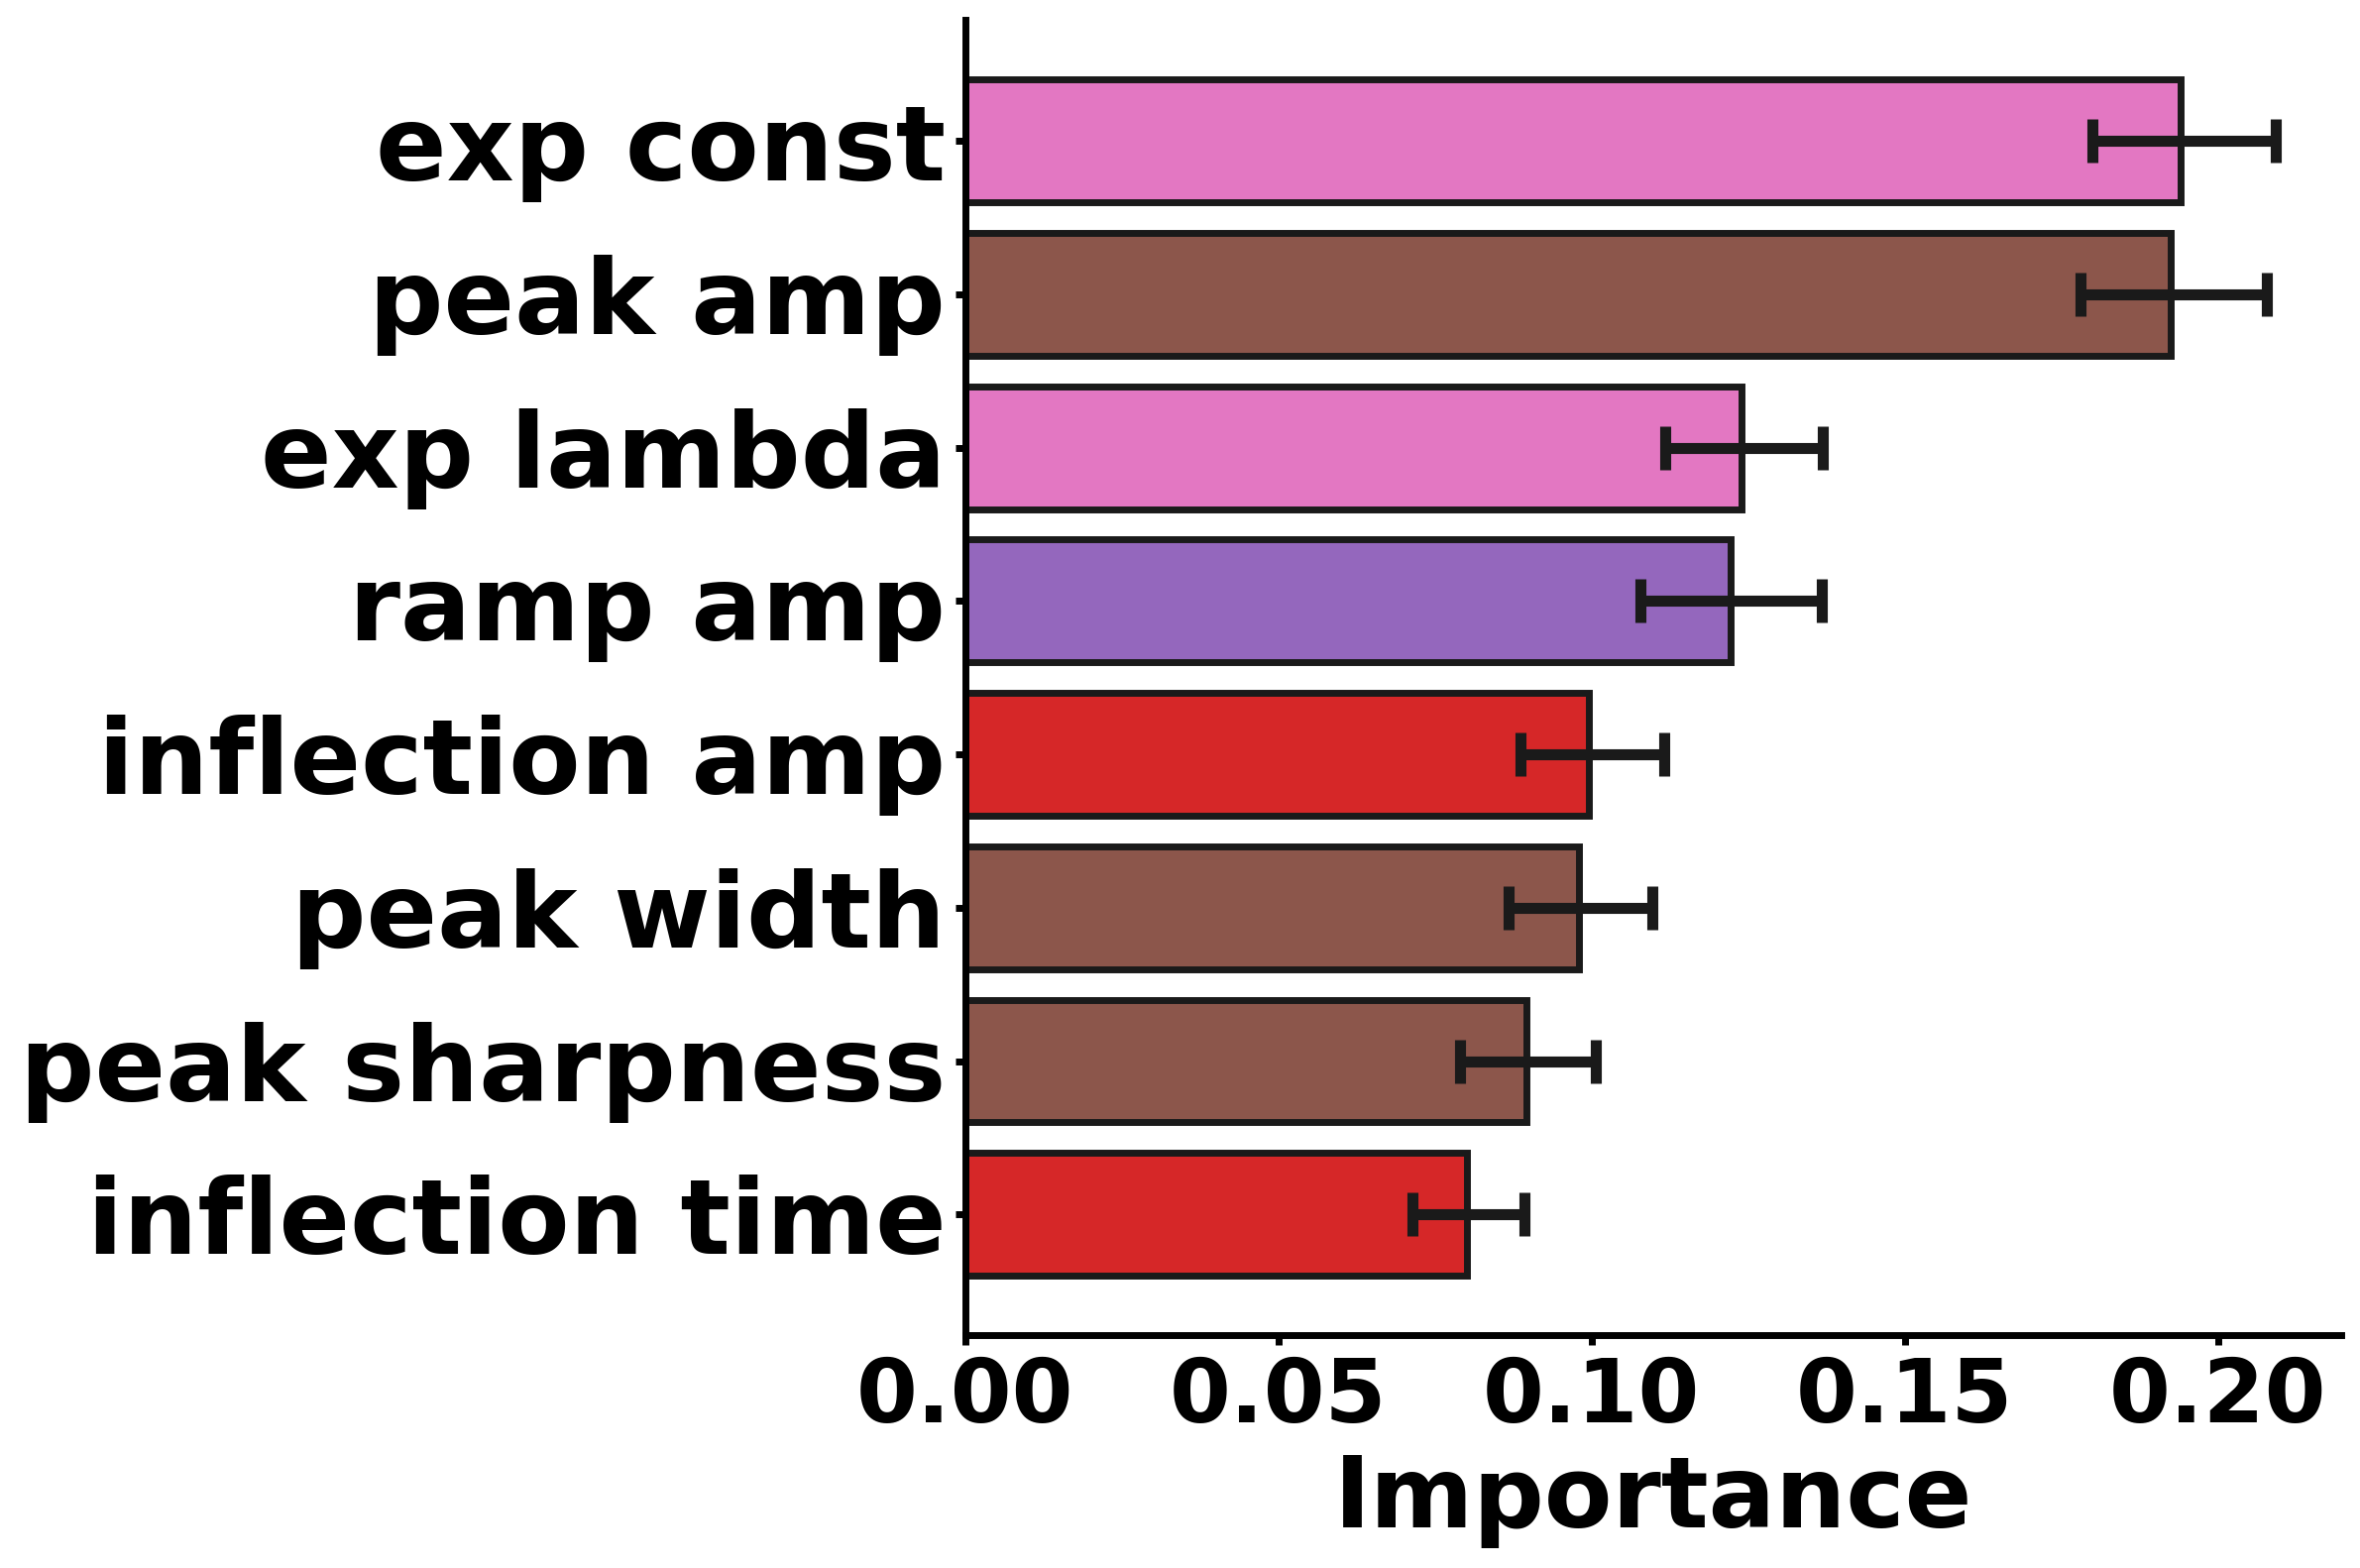

In [3]:
plot_classifier_results(DATA_DIR)

## Part 2: Pink noise deep dive

Because pink noise fluctuates from moment to moment, each spike is preceded by a slightly different stretch of input. That lets us ask a finer question than Part 1: does the shape of a spike reflect the input the neuron received just before it?

### What we extract from the pink noise

For every pink noise spike, we take a window of the injected current that ends at the spike's inflection point (where the spike takes off) and extends back in time. From that window we compute three properties of the input:
- **mean amplitude**: the average injected current;
- **standard deviation**: how much the current fluctuated;
- **spectral exponent**: the slope of the window's power spectrum on log-log axes, a summary of how the input's power is spread across frequencies.

<img src="finding_notebooks_data/paper_figures/fig3_D.png" width="850">

We then use ridge regression to predict each of these input properties from the spike's waveform features (Fig. 3D). Below, the shaded region marks the window on a real pink noise spike, with its mean and standard deviation in the title. Move the slider to change the window; the main figure uses 200 ms.

(Static snapshot. Run this cell to use the interactive controls.)


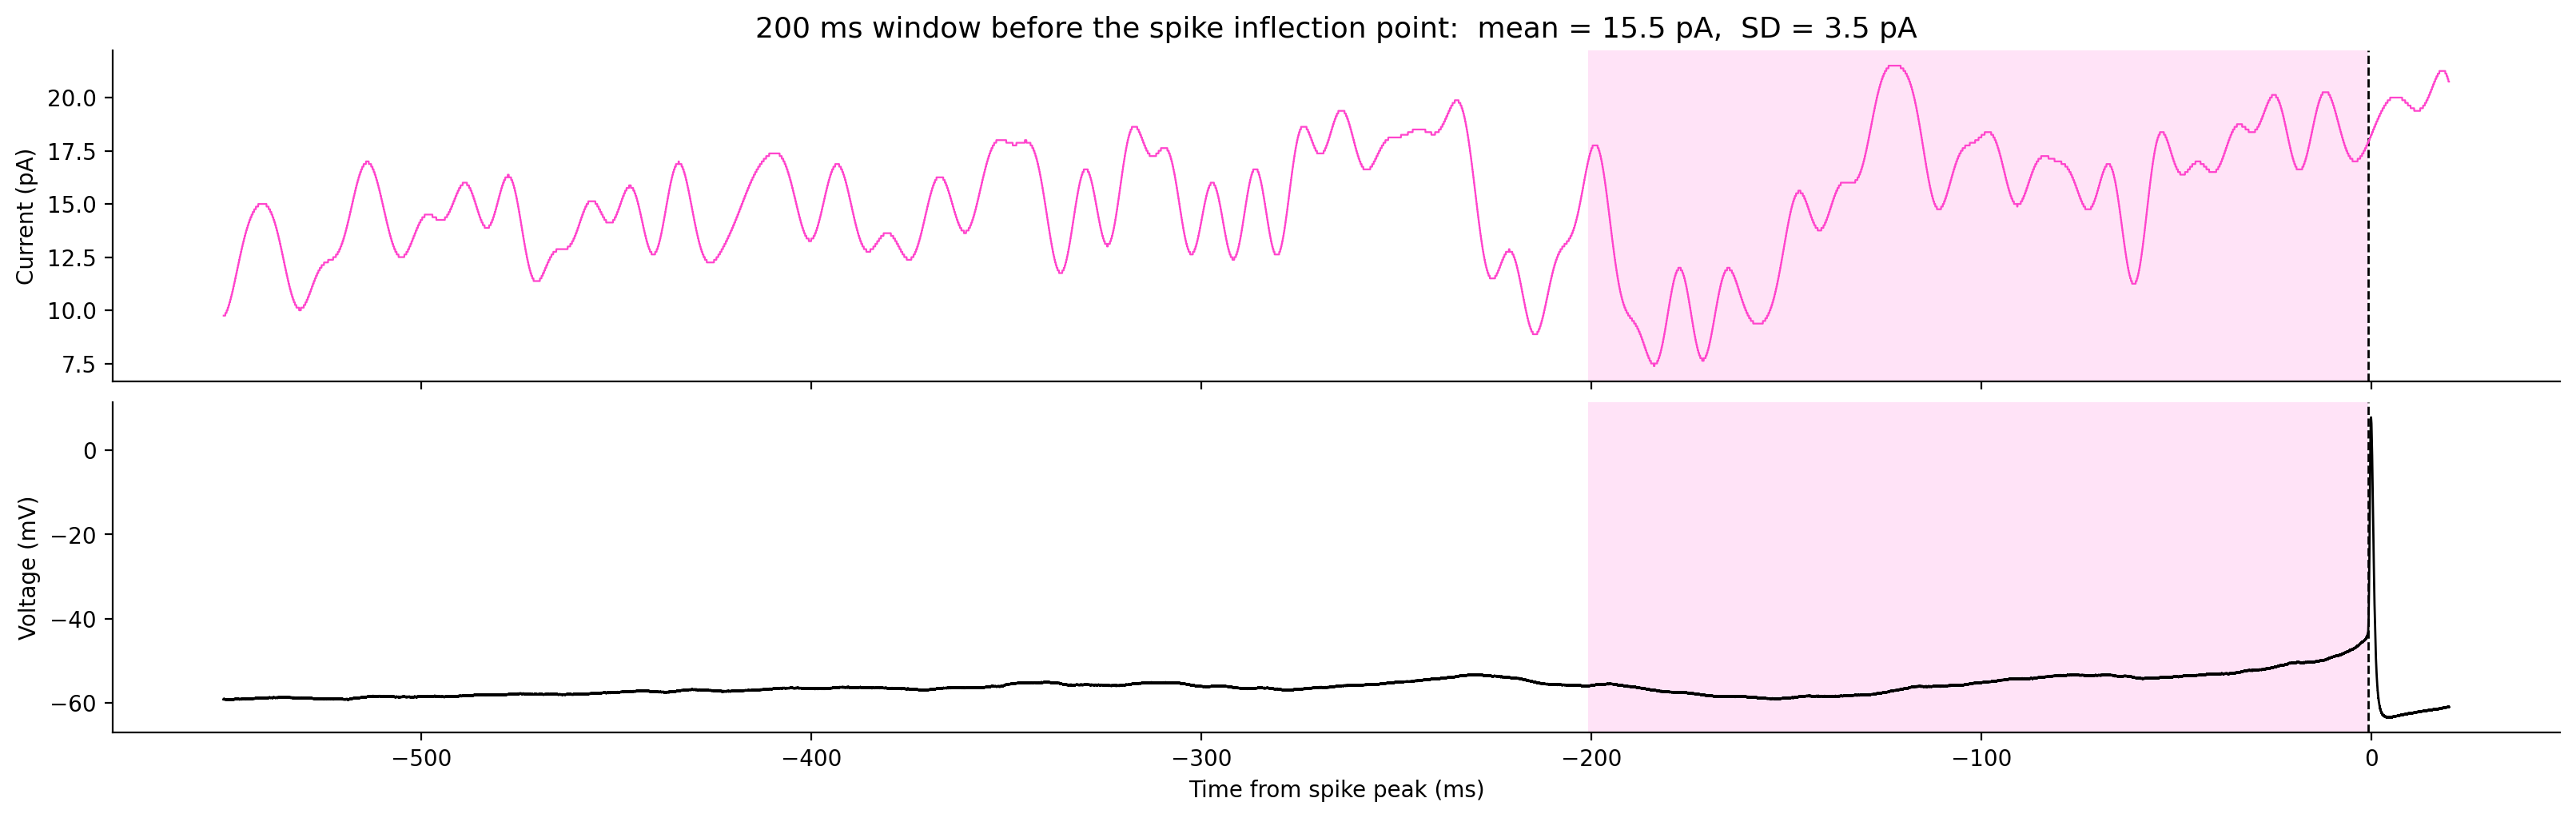

In [4]:
pink_window_schematic_explorer(DATA_DIR, window_ms=200)

### How much input history does the spike reflect?

The window length is a choice, so we repeated the analysis for windows from 5 ms to 500 ms. How well the waveform predicts the input depends on both the window and the input property: prediction of the mean amplitude keeps improving as the window grows, prediction of the standard deviation is best at around 100 ms, and prediction of the spectral exponent levels off from about 200 ms onward. The dashed line is a control in which the input values were shuffled across spikes.

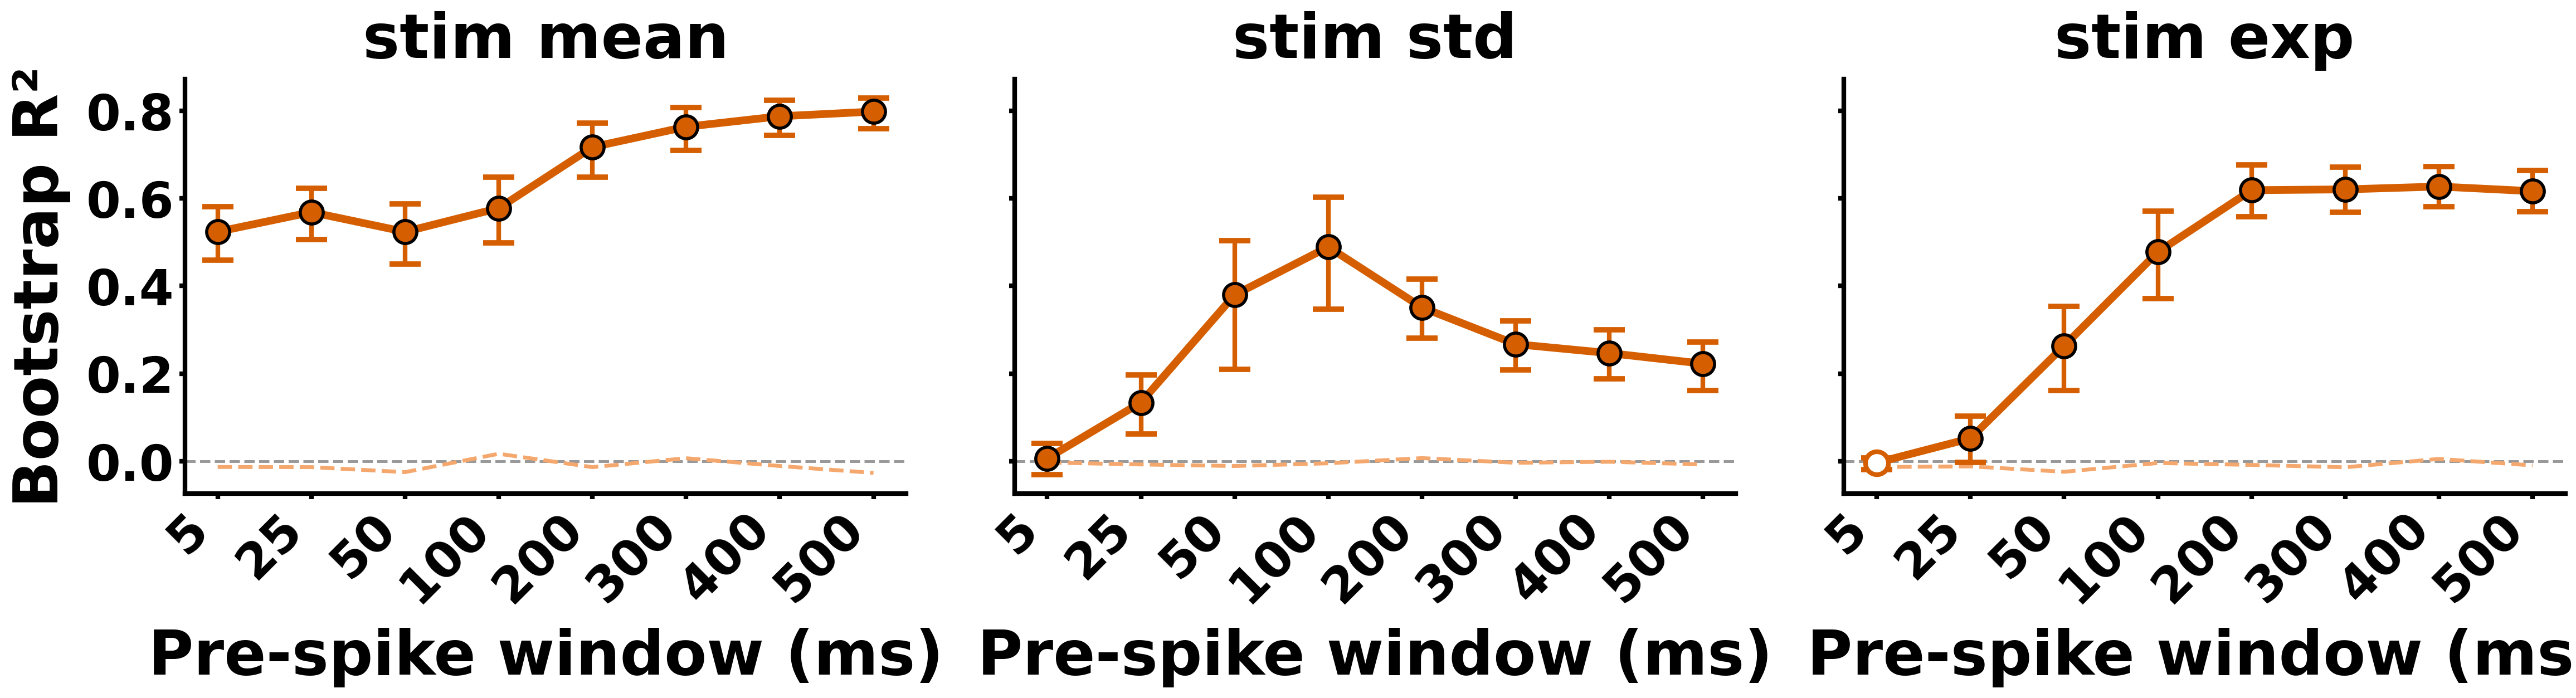

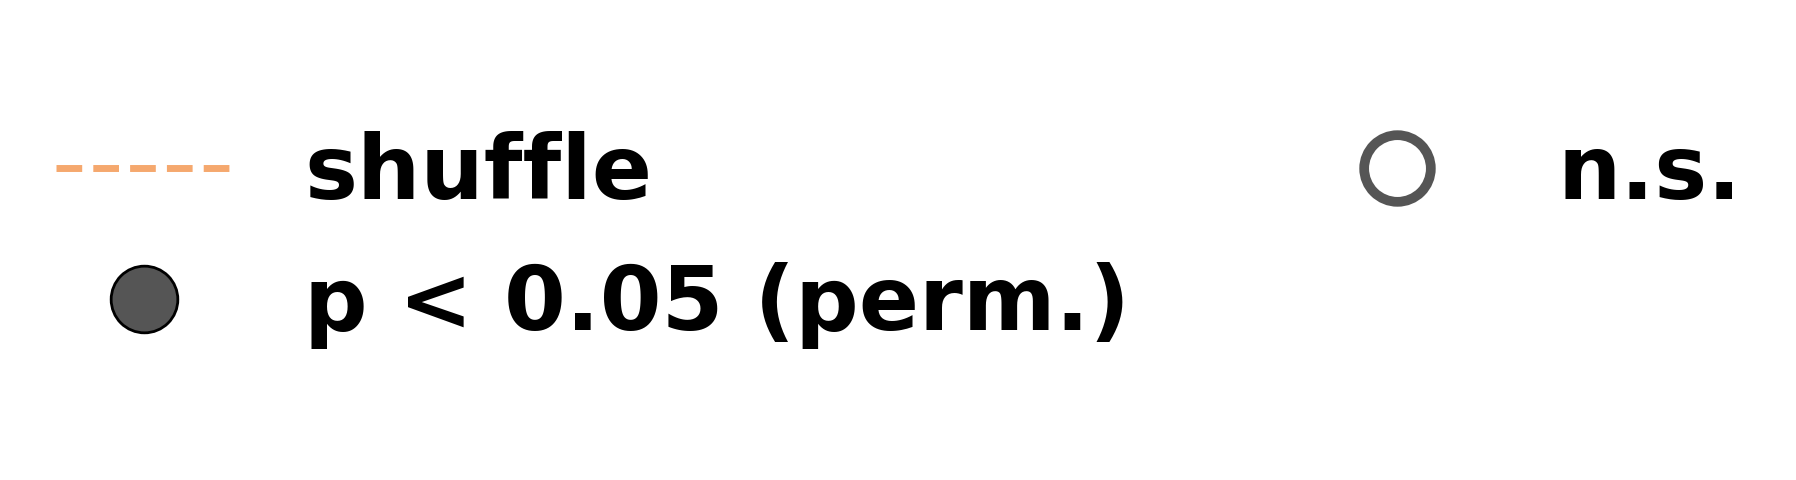

In [5]:
ridge_results = load_ridge_results(DATA_DIR)
plot_r2_across_windows(ridge_results)

### Explore a window

Move the slider to pick a pre-spike window. For that window you will see how the input properties are distributed across all pink noise spikes, the spike features most strongly correlated with each input property (Fig. 3E), and the ridge regression results: R² for each input property and the waveform features that significantly contribute to each prediction (Fig. 3F, G). The paper's main figure uses the 200 ms window.

(Static snapshot. Run this cell to use the interactive controls.)


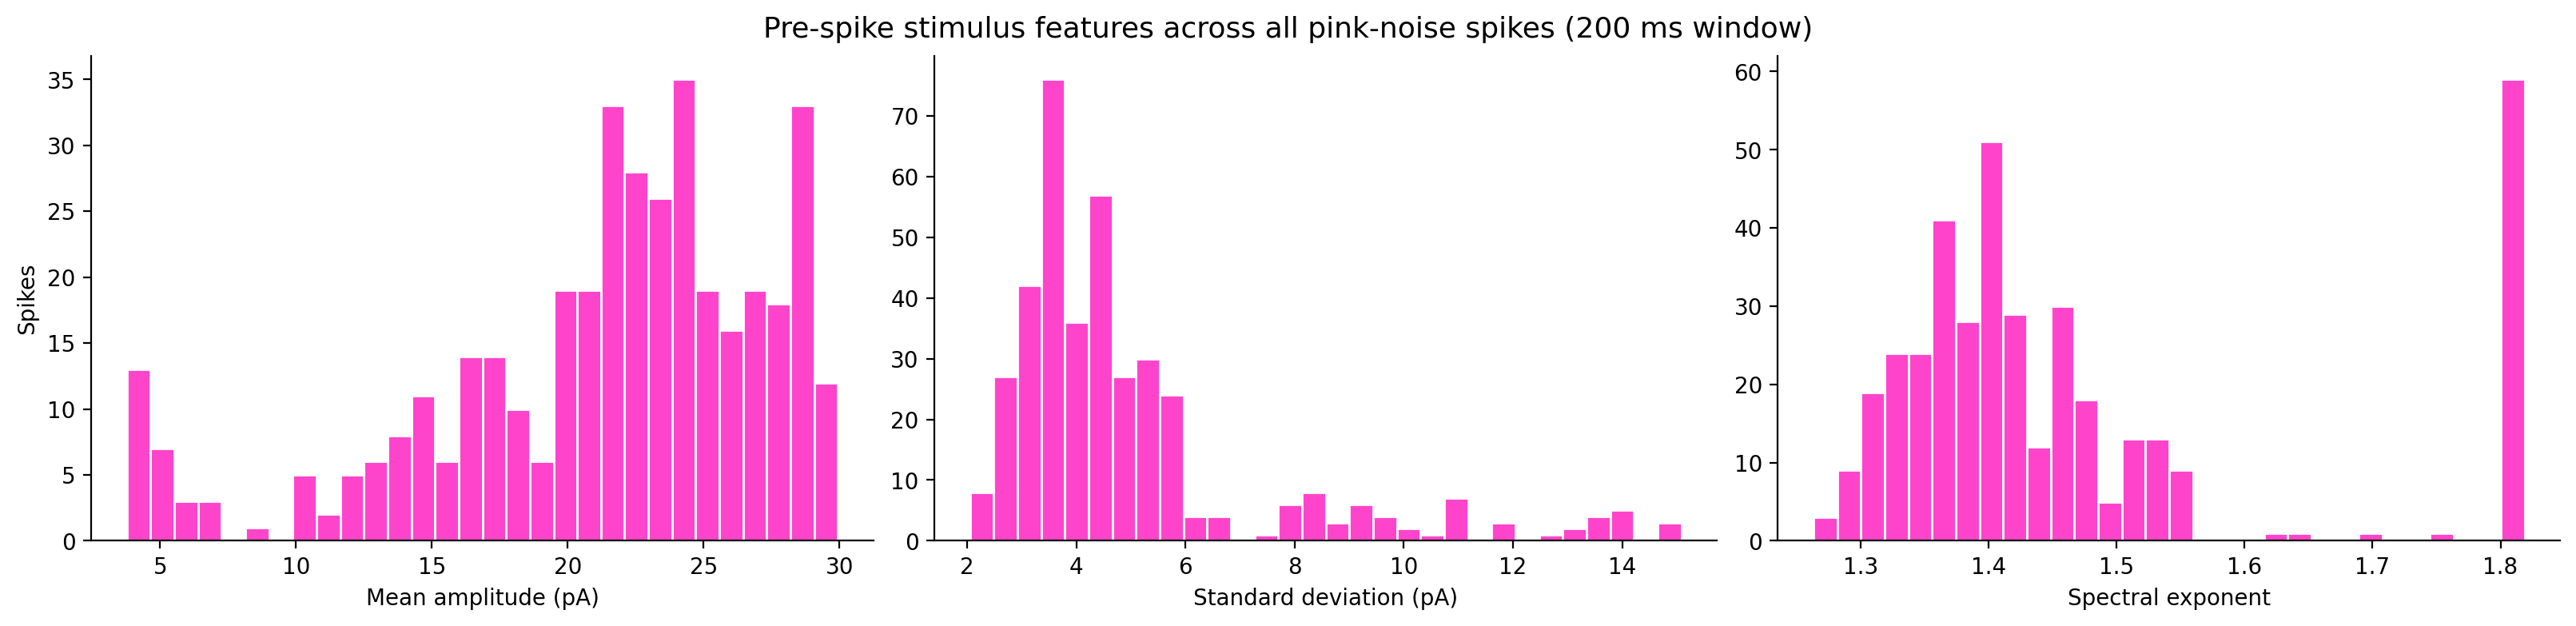

Ridge regression, 200 ms window: how well spike waveform features predict each stimulus feature
  Mean amplitude (pA)      R² = 0.72  95% CI [0.65, 0.77]  permutation p = 0.001
  Standard deviation (pA)  R² = 0.35  95% CI [0.28, 0.42]  permutation p = 0.001
  Spectral exponent        R² = 0.62  95% CI [0.56, 0.68]  permutation p = 0.001


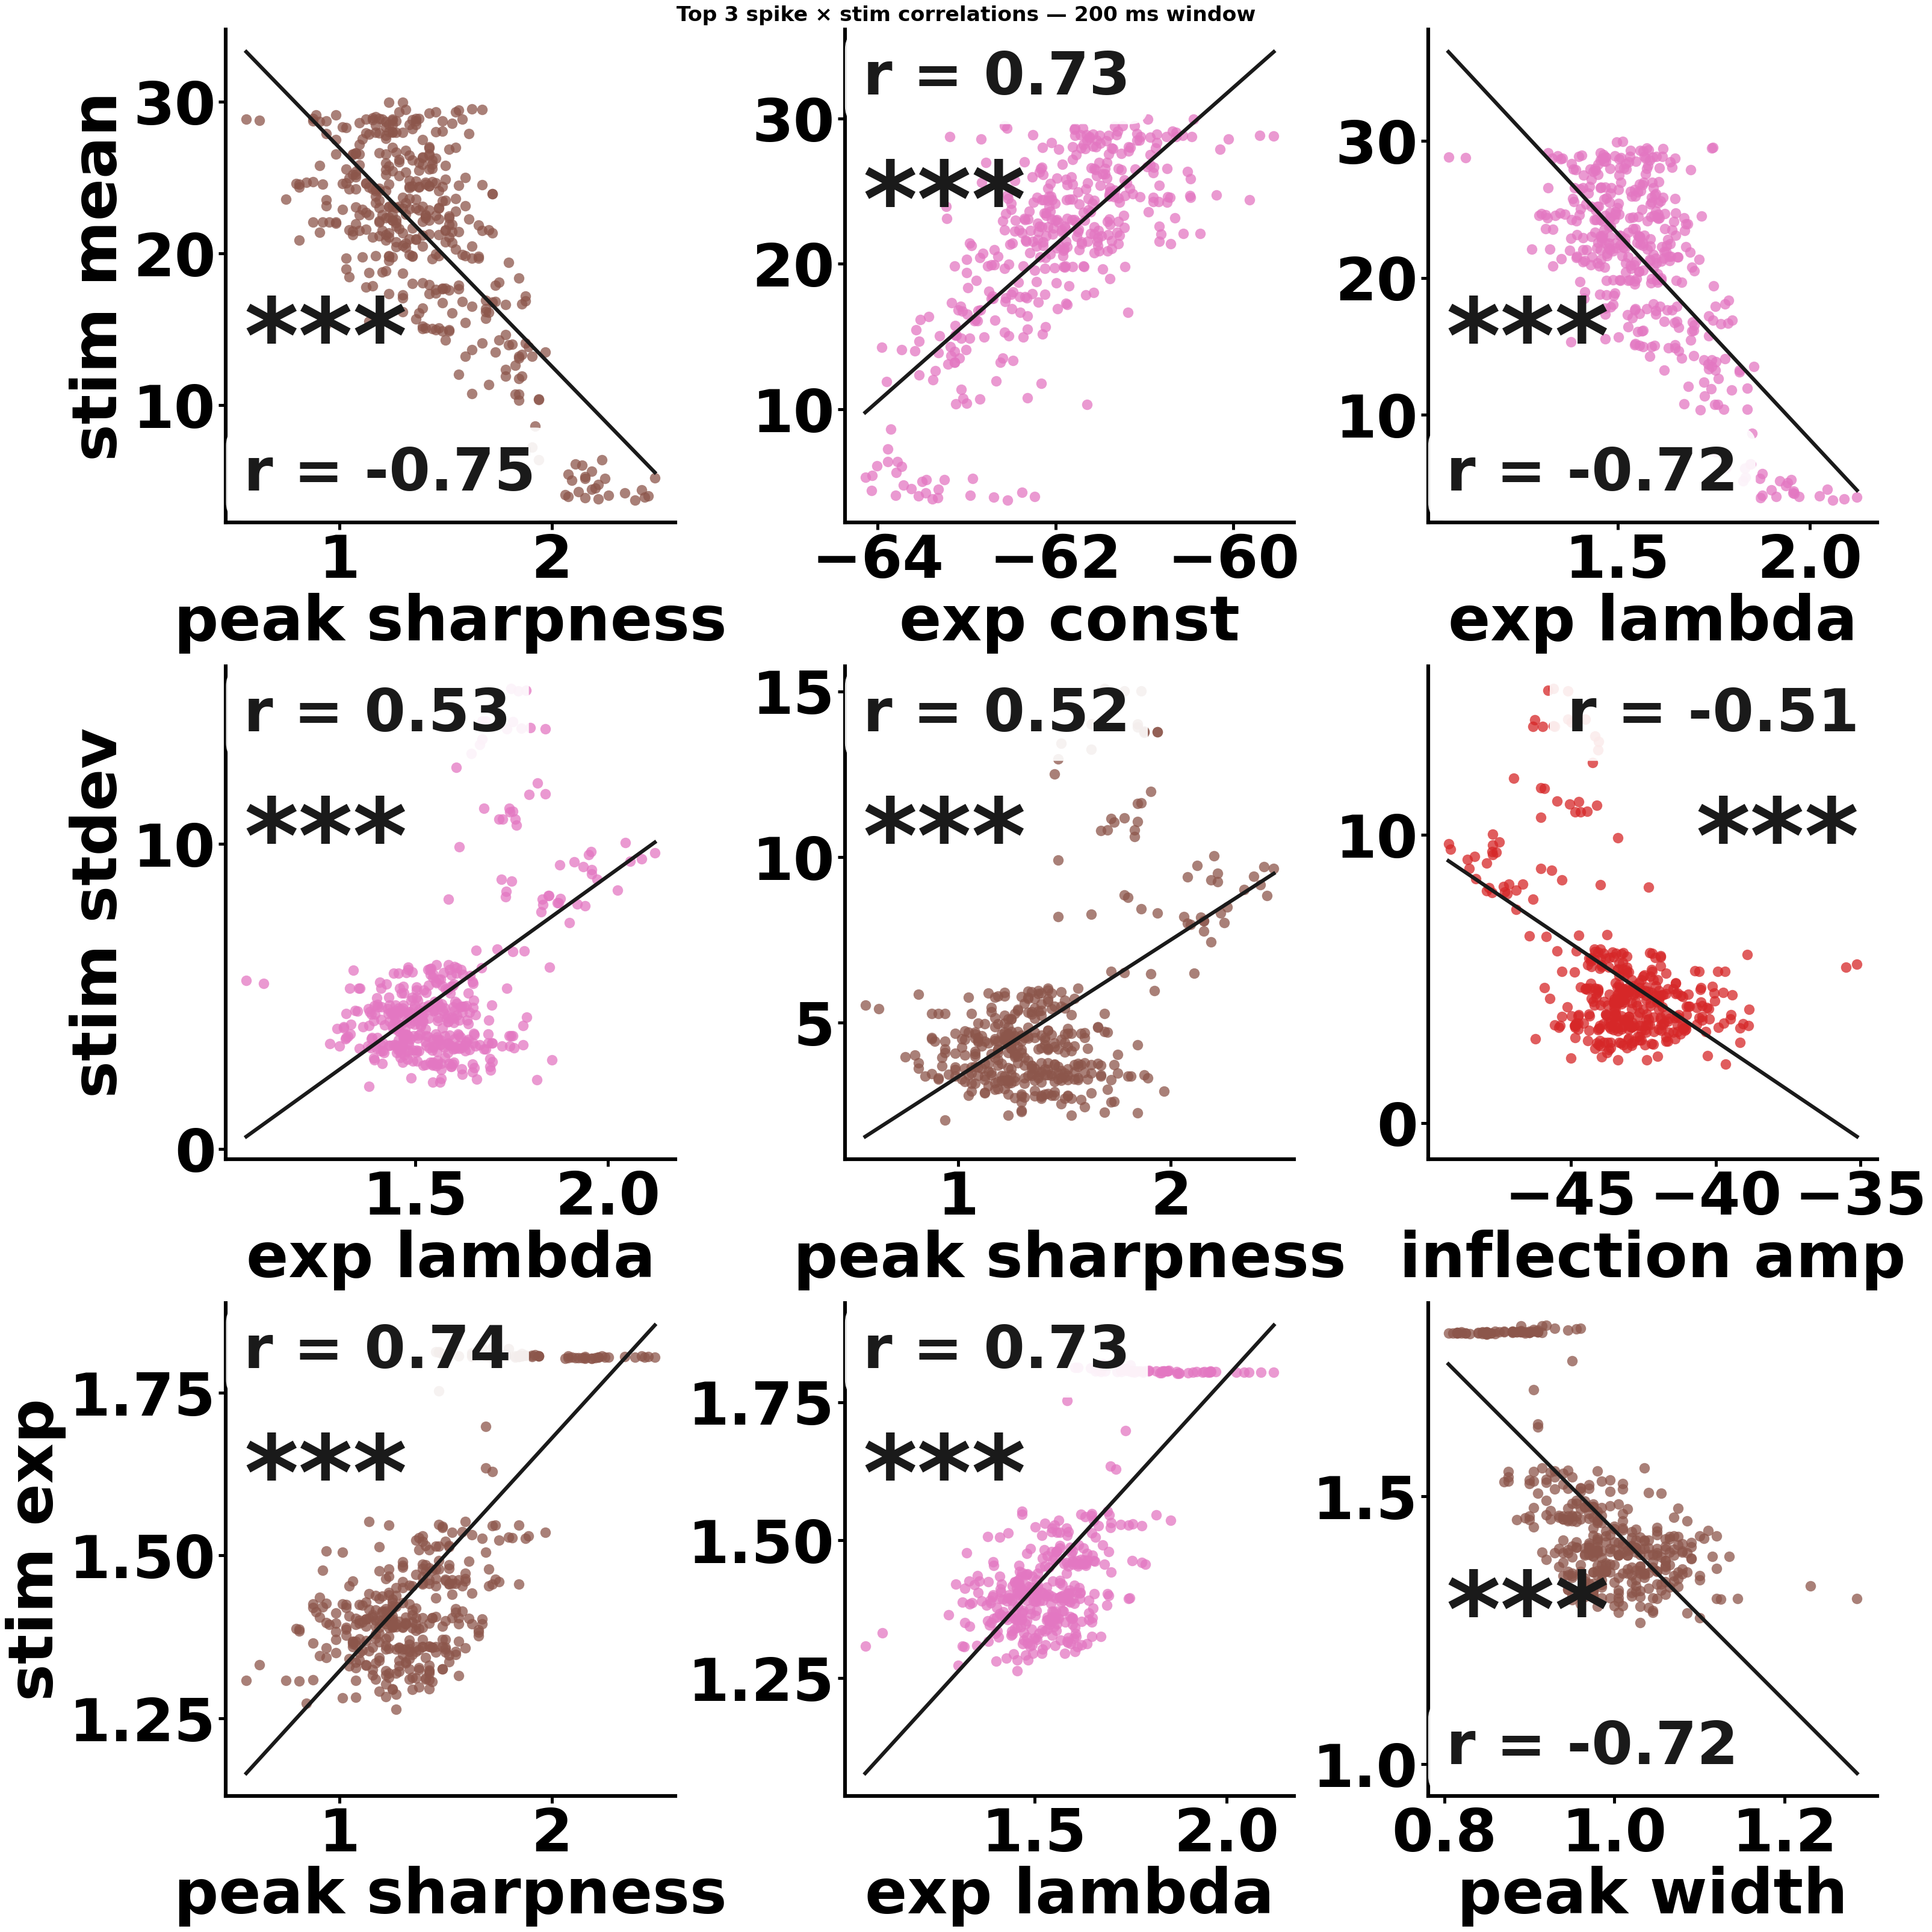

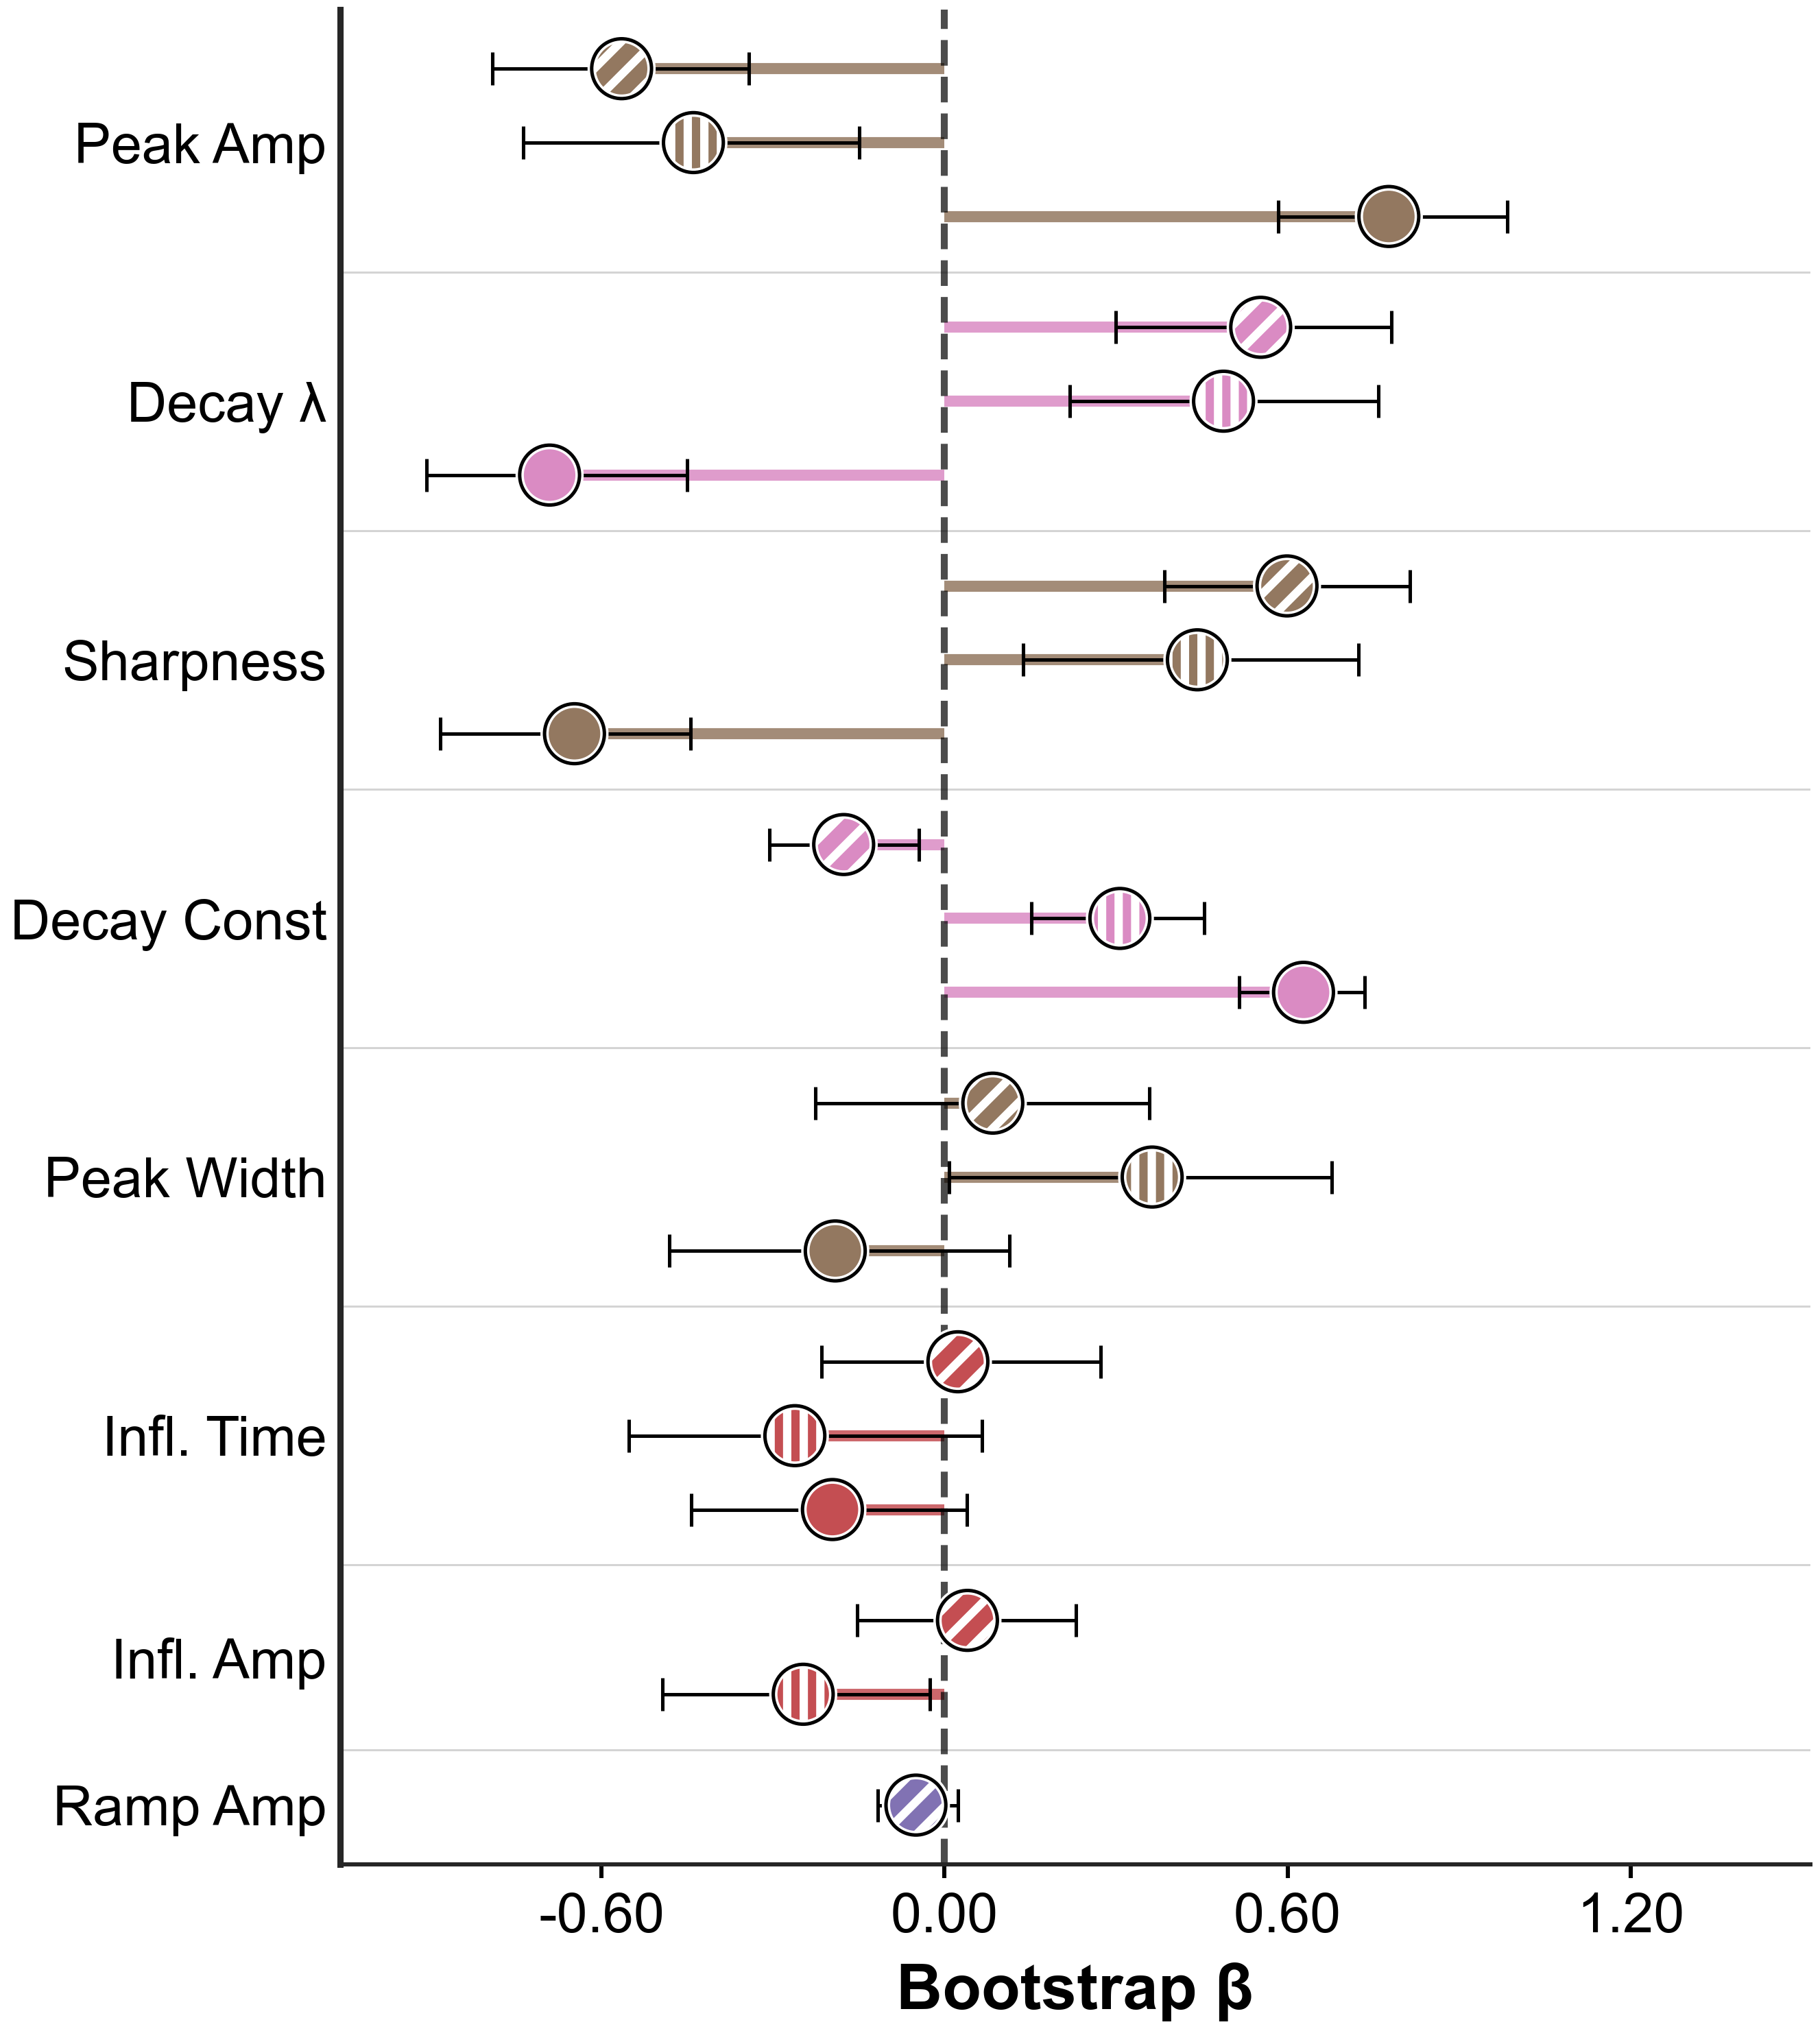

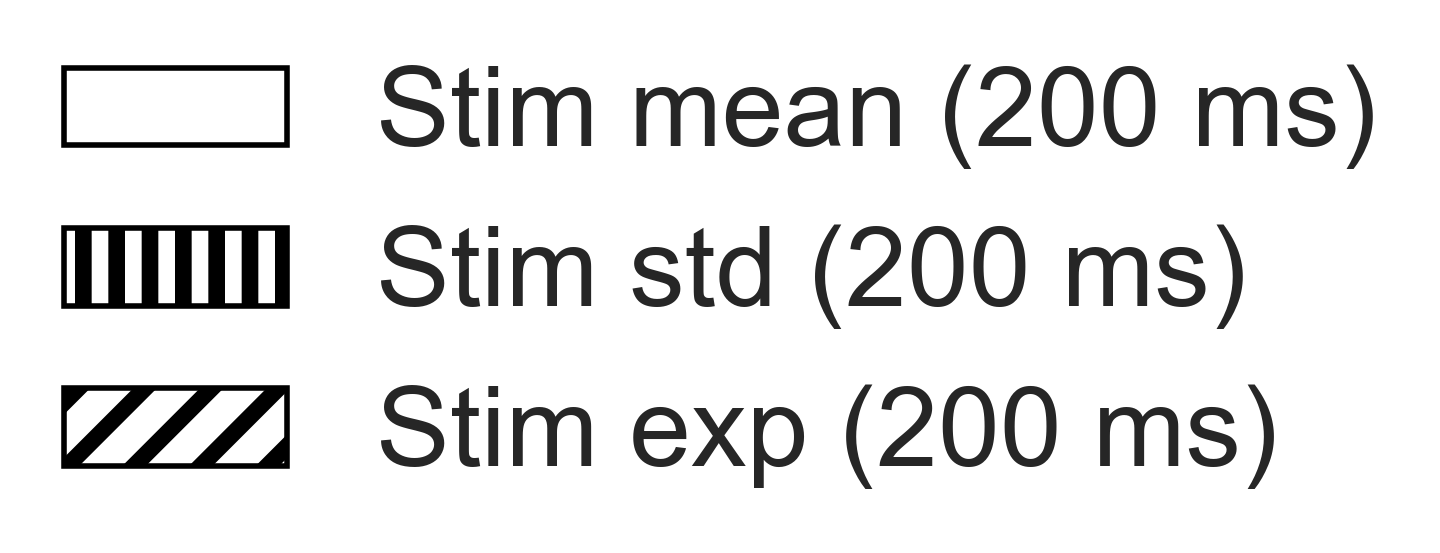

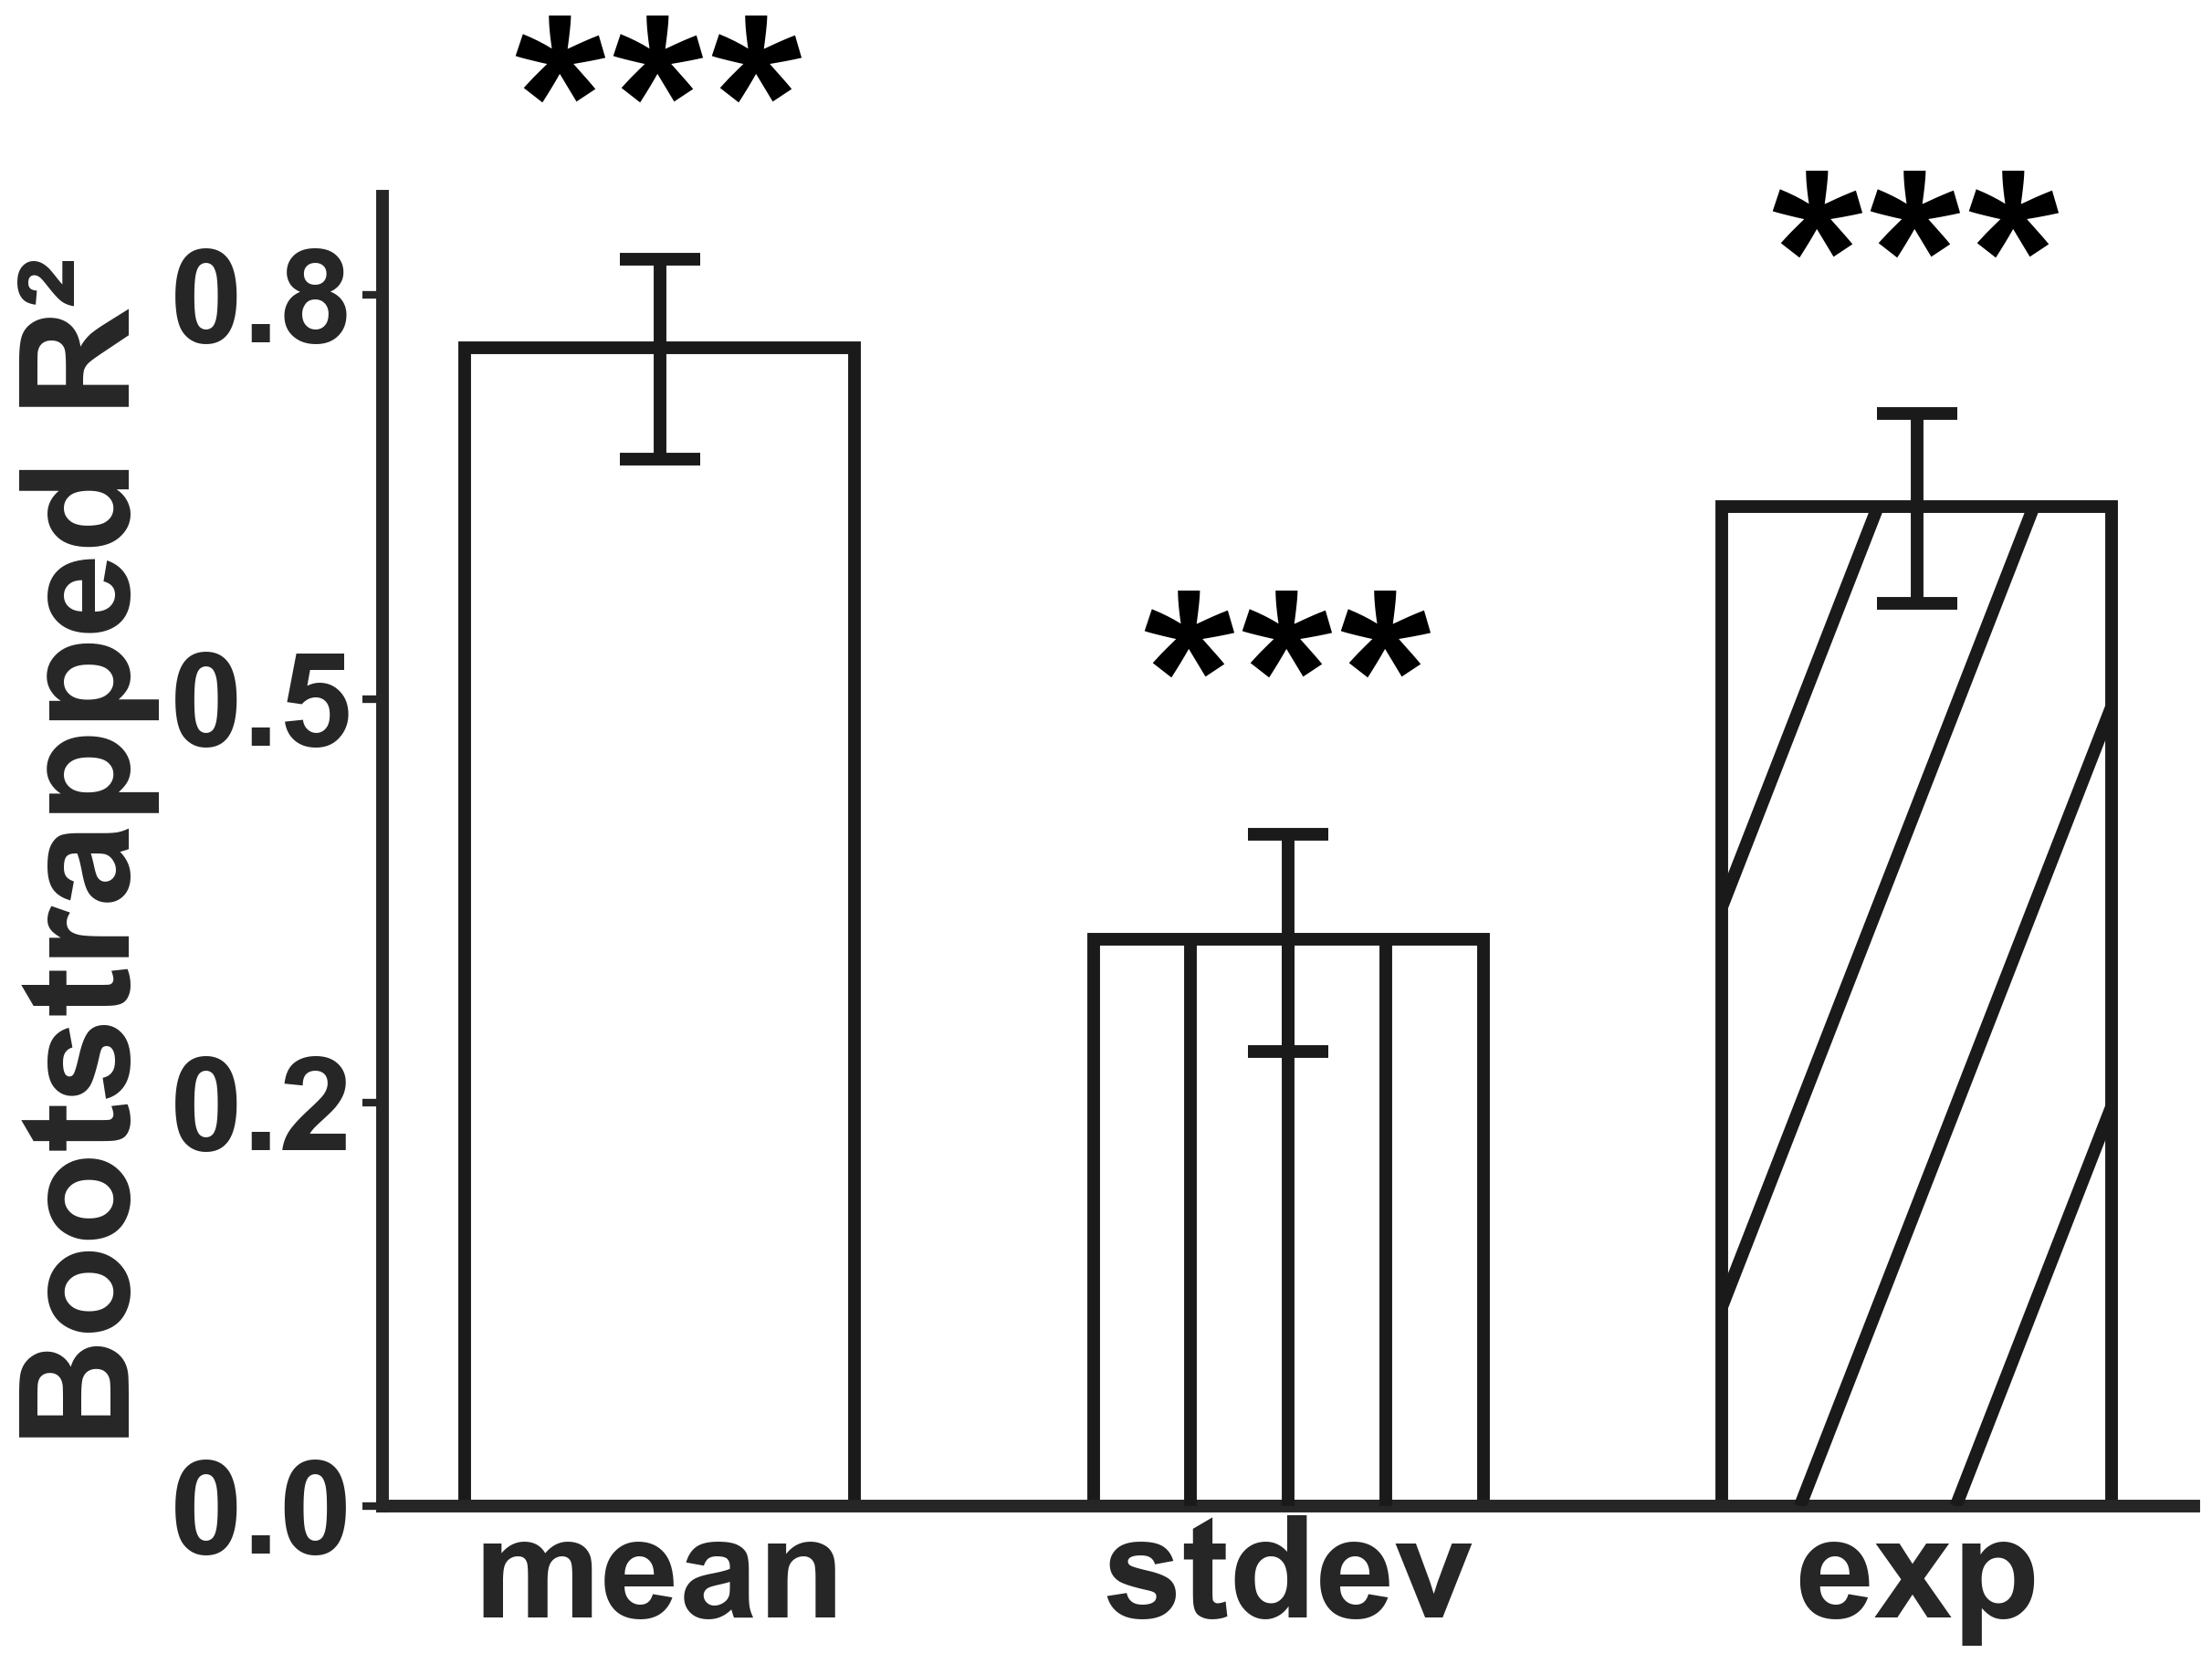

In [6]:
pink_spikes = pd.read_csv(DATA_DIR + 'pink_spikes_by_window.csv.gz')
pink_window_explorer(pink_spikes, ridge_results, window_ms=200)